# 사전에 정의된 체인

- `Stuff`: 모든 문서를 처음부터 끝까지 단일한 프롬프트로 넣어 한 번에 요약. 가장 간단한 접근 방식
- `Map-Reduce`: 각 문서를 Map 단계에서 개별적으로 요약한 다음, Reduce 단계에서 요약본들을 최종 요약본으로 합치는 방식
- `Map-Refine`: 입력 문서를 순회하며 반복적으로 답변을 업데이트하여 응답을 구성. 각 문서에 대해 모든 문서 입력, 현재 문서, 최신 중간 답변을 체인에 전달하여 새로운 답벼능 얻음
- `Chain of Density`: n번 반복 실행하며, 누락된 엔티티를 보완하여 요약보을 개선. 여기서 엔티티란 문서 내에서 의미 있는 핵심 정보를 말함
- `Clustering-Map-Refine`: 문서의 청크를 n개의 클러스터로 나누고, 각 클러스터에서 중시점에 가까운 문서에 대한 요약본을 Refine 방식으로 요약

## 1. Stuff 요약

In [10]:
# !pip install langchain_teddynote

In [11]:
# !pip install python_dotenv

In [12]:
# !pip install langchain_community

In [13]:
from langchain_community.document_loaders import TextLoader
from langchain_teddynote import logging
from dotenv import load_dotenv

load_dotenv()
logging.langsmith("test0914")

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914


In [14]:
# 데이터셋(news.txt) 요약
loader = TextLoader("news.txt", encoding="utf-8")
docs = loader.load()
print(f"총 글자수: {len(docs[0].page_content)}")
print("\n======== 앞부분 미리보기 ========\n")
print(docs[0].page_content[:500])

총 글자수: 1708

======== 앞부분 미리보기 ========

제목: 
AI2, 상업 활용까지 자유로운 '진짜' 오픈 소스 LLM '올모' 출시

내용:
앨런AI연구소(AI2)가 완전한 오픈 소스 대형언어모델(LLM) '올모(OLMo)’를 출시했다. 데이터 수집, 학습, 배포의 전 과정을 투명하게 공개한 데다 상업적 사용까지 허용한 진정한 의미의 오픈 소스 LLM이라는 평가다.
벤처비트는 1일(현지시간) 비영리 민간 AI 연구기관인 AI2가 ‘최초의 진정한 오픈 소스 LLM 및 프레임워크’라고 소개한 ‘올모’를 출시했다고 보도했다. 
이에 따르면 올모는 모델 코드와 모델 가중치뿐만 아니라 훈련 코드, 훈련 데이터, 관련 툴킷 및 평가 툴킷도 제공한다. 이를 통해 모델이 어떻게 구축되었는지 심층적으로 분석, LLM의 작동 방식과 응답을 생성하는 원리를 더 잘 이해할 수 있다. 
올모 프레임워크는 70억 매개변수의 ‘올모 7B’ 등 4가지 변형 모델과 10억 매개변수의 ‘올모 1B’ 모델을 제공한다. 모델들은 훈련 데이터를 생성하는 코드를 포함해 


In [15]:
# !pip install langchainhub

In [16]:
# !pip install -U langsmith langchainhub langchain_classic

In [17]:
from langsmith import Client

client = Client()
prompt = client.pull_prompt(
    "teddynote/summary-stuff-documents-korean", dangerously_pull_public_prompt=True
    )
prompt.pretty_print()

Please summarize the sentence according to the following REQUEST.
REQUEST:
1. Summarize the main points in bullet points in KOREAN.
2. Each summarized sentence must start with an emoji that fits the meaning of the each sentence.
3. Use various emojis to make the summary more interesting.
4. Translate the summary into KOREAN if it is written in ENGLISH.
5. DO NOT translate any technical terms.
6. DO NOT include any unnecessary information.

CONTEXT:
{context}

SUMMARY:"



In [18]:
# 토큰당 과금 비용이 낮은 gpt-4o-mini 버전으로 요약
# StreamingCallBack()은 스트리밍 방식으로 데이터 처리
# create_stuff_documents_chain()은 LLM과 프롬프트를 결합해 체인을 생성하여 전체 문서를 한 번에 넣고 요약
from langchain_openai import ChatOpenAI
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback

llm = ChatOpenAI(
    model="gpt-4o-mini",
    streaming=True,
    temperature=0,
    callbacks=[StreamingCallback()]
)

stuff_chain = create_stuff_documents_chain(llm, prompt)
answer = stuff_chain.invoke({"context": docs})

- 🚀 앨런AI연구소(AI2)가 완전한 오픈 소스 LLM '올모(OLMo)'를 출시했다.  
- 📊 데이터 수집, 학습, 배포 과정을 투명하게 공개하고 상업적 사용을 허용한다.  
- 🔍 올모는 모델 코드, 가중치, 훈련 코드, 데이터 및 평가 툴킷을 제공한다.  
- 🧩 70억 매개변수의 '올모 7B'와 10억 매개변수의 '올모 1B' 모델을 포함한 4가지 변형 모델이 있다.  
- 📈 훈련 데이터는 AI2의 '돌마(Dolma)' 데이터 세트를 기반으로 하며, 3조개의 토큰을 포함한다.  
- 📝 아파치 2.0 라이선스에 따라 상업적 활용에 제한이 없다.  
- 💡 올모는 상업용 제품과 동등한 성능을 보여주며, 일부 자연어 처리 벤치마크에서 우수한 성과를 기록했다.  
- 🌍 비영어권 언어에 대한 낮은 품질과 약한 코드 생성 기능이 제약 사항으로 지적되었다.  
- 🔧 AI2는 올모를 계속해서 향상할 계획이다.  
- 🌐 현재 올모의 모든 리소스는 깃허브 및 허깅페이스에서 무료로 제공된다.  

In [19]:
# 만약 자신이 원하는 프로프트를 적용하고 싶다면 다음과 같이 프롬프트를 작성
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    """Please summarize the sentence according to the forllowing REQUEST.
    REQUEST:
    ...
    CONTEXT:
    {context}
    
    SUMMARY:
    """
)

prompt.pretty_print()

Please summarize the sentence according to the forllowing REQUEST.
    REQUEST:
    ...
    CONTEXT:
    {context}

    SUMMARY:
    


## 2. Map-Reduce 요약

`Map-Reduce` 방식은 대규모 무서를 언어 모델의 토큰 제한에 구애받지 않고 효율적으로 요약하는 기법.

문서를 작은 청크로 나누는 Map 단계와 각 청크의 요약을 결합하는 Reduce 단계로 구성.

Map 단계에서는 전체 문서를 특정한 기준에 따라 청크로 나눠 각 청크마다 요약을 만듬.

이때 일반적인 텍스트 분할의 청크보다는 더 큰 페이지 단위로 분할하는 편.

Reduce 단계에서는 이 요약본들을 하나의 최종 요약본으로 통합.

In [20]:
# !pip install pypdf

In [21]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("SPRI_AI_Brief_2023년12월호_F (1).pdf")
docs = loader.load()
docs = docs[3:8] # 문서의 일부만 요약
print(f"총 페이지수: {len(docs)}")

총 페이지수: 5


In [22]:
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(temperature=0, model="gpt-4o-mini")

client = Client()
map_prompt = client.pull_prompt("teddynote/map-prompt", dangerously_pull_public_prompt=True) # map_prompt 다운로드

map_prompt.pretty_print() # 보기 좋게 프롬프트 출력

================================ System Message ================================

You are a professional main thesis extractor.

================================ Human Message =================================

Your task is to extract main thesis from given documents. Answer should be in same language as given document. 

#Format: 
- thesis 1
- thesis 2
- thesis 3
- ...

Here is a given document: 
{doc}

Write 1~5 sentences.
#Answer:


In [23]:
map_chain = map_prompt | llm | StrOutputParser()

doc_summaries = map_chain.batch(docs)

print(doc_summaries[0])

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 미국 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 모범사례를 개발해야 한다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서 책임 있는 AI 사용을 촉진하고, AI로 인한 근로자 피해를 완화하는 원칙을 마련할 예정이다.
- 국가AI연구자원(NAIRR)을 통해 미국 전역의 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 취업할 수 있도록 지원할 계획이다.


In [24]:
# reduce prompt 다운로드
client = Client()
reduce_prompt = client.pull_prompt("teddynote/reduce-prompt", dangerously_pull_public_prompt=True)

# 프롬프트 출력
reduce_prompt.pretty_print()

================================ System Message ================================

You are a professional summarizer. You are given a list of summaries of documents and you are asked to create a single summary of the documents.

================================ Human Message =================================

#Instructions: 
1. Extract main points from a list of summaries of documents
2. Make final summaries in bullet points format.
3. Answer should be written in {language}.

#Format: 
- summary 1
- summary 2
- summary 3
- ...

Here is a list of summaries of documents: 
{doc_summaries}

#SUMMARY:


In [25]:
# 체인 생성
reduce_chain = reduce_prompt | llm | StrOutputParser()

In [26]:
from langchain_teddynote.messages import stream_response

answer = reduce_chain.stream(
    {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
)

stream_response(answer)

- 미국 바이든 대통령이 AI 개발과 사용의 안전성을 보장하기 위한 행정명령을 발표하였다.
- 행정명령은 AI의 안전 기준, 개인정보 보호, 형평성, 소비자 보호, 노동자 지원, 혁신 촉진, 국제협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과를 정부와 공유하고, 책임 있는 사용을 위한 모범사례를 개발해야 한다.
- 의료 분야에서 AI의 책임 있는 사용을 촉진하고 근로자 피해를 완화하는 원칙을 마련할 예정이다.
- G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였다.
- 행동강령은 AI의 위험 평가, 투명성 보장, 정보 공유 및 협력을 요구한다.
- G7은 AI 생성 콘텐츠의 신뢰성을 높이기 위한 인증 및 출처 확인 메커니즘 개발을 제안하였다.
- 28개국이 AI 안전성 정상회의에서 AI 시스템의 안전 보장을 위한 블레츨리 선언을 발표하였다.
- 영국 총리는 AI 안전 연구소 출범과 안전성 시험 계획 수립을 발표하였다.
- 미국 법원은 생성 AI 기업에 대한 저작권 침해 소송을 기각하였다.
- FTC는 생성 AI로 인한 소비자와 창작자의 피해 가능성을 경고하고, 시장 지배력 강화 우려를 표명하였다.
- FTC는 소비자 보호와 공정한 경쟁 시장 유지를 위해 모든 권한을 활용하겠다고 강조하였다.

In [27]:
from langchain_core.runnables import chain

@chain
def map_reduce_chain(docs):
    map_llm = ChatOpenAI(
        temperature=0, model="gpt-4o-mini"
    )

    # map_prompt 다운로드
    client = Client()
    map_prompt = client.pull_prompt("teddynote/map-prompt", dangerously_pull_public_prompt=True)

    # map chain 생성
    map_chain = map_prompt | llm | StrOutputParser()

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성
    doc_summaries = map_chain.batch(docs)

    #reduce_prompt 다운로드
    client = Client()
    reduce_prompt = client.pull_prompt("teddynote/reduce-prompt", dangerously_pull_public_prompt=True)
    reduce_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True
    )

    reduce_chain = reduce_prompt | llm | StrOutputParser()

    return reduce_chain.invoke(
        {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
    )

In [28]:
answer = map_reduce_chain.invoke(docs)
print(answer)

- 미국 바이든 대통령이 AI 개발과 사용의 안전성을 보장하기 위한 행정명령을 발표하였다.
- 행정명령은 AI의 안전 기준, 개인정보 보호, 형평성, 소비자 보호, 노동자 지원, 혁신 촉진, 국제협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과를 정부와 공유하고, 책임 있는 사용을 위한 모범사례를 개발해야 한다.
- 의료 분야에서 AI의 책임 있는 사용을 촉진하고 근로자 피해를 완화하는 원칙을 마련할 예정이다.
- G7은 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였다.
- 이 행동강령은 AI의 위험 평가, 투명성 보장, 정보 공유를 요구한다.
- G7은 AI 생성 콘텐츠의 신뢰성을 높이기 위한 인증 메커니즘 개발을 제안하였다.
- 28개국이 AI 안전성 정상회의에서 AI 안전 보장을 위한 블레츨리 선언을 발표하였다.
- 영국 총리는 AI 안전 연구소 출범과 안전성 시험 계획 수립을 발표하였다.
- 미국 법원은 생성 AI 기업에 대한 저작권 침해 소송을 기각하였으나, 일부 소송은 계속 진행 중이다.
- 미국 연방거래위원회(FTC)는 생성 AI의 소비자 피해 가능성과 빅테크의 시장 지배력 우려를 표명하였다.
- FTC는 소비자 보호와 공정한 경쟁 시장 유지를 위해 법적 권한을 활용하겠다고 강조하였다.


## 2. Map-Refine 요약

`Map-Refine` 방식은 Map-Reduce의 Map 단계는 동일하지만, Reduce 단계 대신 생성된 요약을 순차적으로 처리함으로써 최종 요약본을 점진적으로 개선.

Ex: Map 단계에서 4 개의 요약본 청크를 만들었다고 가정 -> 1번 요약본을 2번 요약본과 종합해서 하나의 요약본을 만듦 -> 3번 요약본과 합침

이런 식으로 모든 청크가 처리될 때까지 Refine 단계를 반복하여 최종 요약본을 만들어 냄.

Map-Reduce: 여러 요약본을 한 번에 합치는 과정에서 요약본의 순서가 바뀔 수 있음

Map-Refine: 요약본을 순서대로 처리하므로 문서의 맥락이 어느 정도 유지된다는 장점이 있음.

`다만` 여러 차례 반복 과정이 필요하므로 비용과 시간이 더 듬.

내용의 흐름이 중요: Map-Refine

빠른 처리가 중요: Map-Reduce

In [29]:
from dotenv import load_dotenv
load_dotenv()
from langchain_teddynote import logging
logging.langsmith("test0914")
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# map_llm 생성
map_llm = ChatOpenAI(
    temperature=0,
    model="gpt-4o-mini"
)

# map_summary 생성
client = Client()
map_summary = client.pull_prompt("teddynote/map-summary-prompt", dangerously_pull_public_prompt=True)

map_summary.pretty_print() # 프롬프트 출력

LangSmith 추적을 시작합니다.
[프로젝트명]
test0914
================================ System Message ================================

You are an expert summarizer. Your task is to summarize the following document in {language}.

================================ Human Message =================================

Extract most important main thesis from the documents, then summarize in bullet points.

#Format:
- summary 1
- summary 2
- summary 3
-...

Here is a given document: 
{documents}

Write 1~5 sentences. Think step by step.
#Summary:


In [30]:
# map chain 생성
map_chain = map_summary | llm | StrOutputParser()

# 첫 번째 문서의 요약 출력
print(map_chain.invoke({"documents": docs[0], "language": "Korean"}))

- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.
- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.
- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 지침이 마련된다.
- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.
- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.


In [31]:
# 리스트 내포(list comprehension)를 사용하여 요약본 docs 리스트의 각 항목(doc)에 대해 새로운 딕셔너리를 생성
# input_doc 변쉐 각 요약본을 한국어로 요약하기 위한 정보를 포함한 딕셔너리를 리스트 형식으로 입력
input_doc = [{"documents": doc, "language": "Korean"} for doc in docs]
input_doc

[{'documents': Document(metadata={'producer': 'Hancom PDF 1.3.0.542', 'creator': 'Hwp 2018 10.0.0.13462', 'creationdate': '2023-12-08T13:28:38+09:00', 'author': 'dj', 'moddate': '2023-12-08T13:28:38+09:00', 'pdfversion': '1.4', 'source': 'SPRI_AI_Brief_2023년12월호_F (1).pdf', 'total_pages': 23, 'page': 3, 'page_label': '4'}, page_content='1. 정책/법제  2. 기업/산업 3. 기술/연구  4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 \nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고 \n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 \n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\nKEY Contents\n£ 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 \n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호 \n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한 \n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및 \nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n∙ △1026 플롭스(FLOPS, Float

In [32]:
# batch를 이용해 다섯 페이지에 대한 Map 요약을 수행
print(map_chain.batch(input_doc))

['- 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용을 위한 행정명령을 발표하였다.\n- 이 행정명령은 AI의 안전과 보안 기준, 개인정보 보호, 형평성과 시민권 향상, 소비자 보호, 노동자 지원, 혁신과 경쟁 촉진, 국제 협력을 포함한다.\n- AI 시스템 개발 기업은 안전 테스트 결과와 시스템 정보를 정부와 공유해야 하며, AI의 책임 있는 사용을 위한 지침이 마련된다.\n- 소비자 보호와 근로자 지원을 위해 의료 분야에서의 AI 사용 촉진 및 교육 도구 개발이 강조된다.\n- 국가 AI 연구 자원을 통해 AI 연구를 촉진하고, 외국인 전문가들이 미국에서 공부하고 일할 수 있도록 지원하는 방안도 포함된다.', "- G7은 2023년 10월 30일 '히로시마 AI 프로세스'를 통해 AI 기업을 위한 국제 행동강령에 합의하였다.\n- 이 행동강령은 AI 시스템의 위험 식별 및 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반에 걸친 위험 평가와 투명성, 책임성을 강조한다.\n- 주요 내용으로는 정보 공유, 협력, 보안 통제, 콘텐츠 인증 및 출처 확인 메커니즘 개발 등이 포함된다.\n- G7은 기술 발전에 대응하기 위해 이해관계자 협의를 통해 행동강령을 필요에 따라 개정할 예정이다.\n- 또한, 사회적 위험 완화와 글로벌 문제 해결을 위한 AI 시스템 개발을 우선시하고, 개인정보 보호를 위한 적절한 보호 장치를 구현할 계획이다.", '- 28개국이 영국 블레츨리 파크에서 열린 AI 안전성 정상회의에서 AI 안전 보장을 위한 블레츨리 선언을 발표했다.\n- 선언은 AI 시스템의 안전성을 보장하기 위해 모든 이해관계자의 협력이 필요하다고 강조하며, 특히 AI 개발 기업의 책임을 지적했다.\n- 영국 총리는 AI 안전 연구소의 출범과 함께 첨단 AI 모델에 대한 안전성 시험 계획을 발표하고, 각국 정부는 테스트 결과를 공유하기로 합의했다.\n- 참가국들은 AI 위험과 가능성에 대한 과학적 평가를 위한 보고서 작성을 합의하고, 한국은 영국과 

In [ ]:
# Refine 단계에서는 이전 Map 단계에서 생성한 요약본 청크들을 순차적으로 처리하며 최종 요약본을 점진적으로 개선.
# 먼저 refine-prompt를 다운로드해서 출력, 프롬프트의 Human Message를 보면 이전에 진행한 요약본(previous_summary)과 지금 합쳐 줄 요약본(current_summary)을 각각 넣어서 최종 요약본을 마드는 과정을 진행
client = Client()
refine_prompt = client.pull_prompt("teddynote/refine-prompt", dangerously_pull_public_prompt=True)

refine_prompt.pretty_print()

================================ System Message ================================

You are an expert summarizer.

================================ Human Message =================================

Your job is to produce a final summary

We have provided an existing summary up to a certain point:
{previous_summary}

We have the opportunity to refine the existing summary(only if needed) with some more context below.
------------
{current_summary}
------------
Given the new context, refine the original summary in {language}.
If the context isn't useful, return the original summary.


In [34]:
# refine_llm을 생성하고 이전에 만든 프롬프트와 연결해 체인을 구성
refine_llm = ChatOpenAI(    # refine_llm 생성
    temperature=0,
    model="gpt-4o-mini"
)

# refine_chain 생성
refine_chain = refine_prompt | llm | StrOutputParser()

In [39]:
# map_reduce_chain을 생성하는 예시
# Python 데코레이터를 이용해 지금까지의 일련의 과정을 하나의 체인으로 엮음
from langchain_core.runnables import chain

@chain
def map_refine_chain(docs):

    # map_chain 생성
    client = Client()
    map_summary = client.pull_prompt("teddynote/map-summary-prompt", dangerously_pull_public_prompt=True)

    map_chain = (
        map_summary
        | ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0
        )
        | StrOutputParser()
    )

    input_doc = [{"documents": doc.page_content, "language": "Korean"}for doc in docs]

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성
    doc_summaries = map_chain.batch(input_doc)

    refine_prompt = client.pull_prompt("teddynote/refine-prompt", dangerously_pull_public_prompt=True)

    refine_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        callbacks=[StreamingCallback()],    # 스트리밍 출력
        streaming = True
    )

    refine_chain = refine_prompt | llm | StrOutputParser()

    previous_summary = doc_summaries[0]

    for current_summary in doc_summaries[1:]:

        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean"
            }
        )
        print("\n\n---------------\n\n")

    return previous_summary

In [40]:
# map_reduce_chain에 invoke() 메서드를 호출해 요약할 페이지를 입력
# 출력 결과를 보면 순차적으로 정제된 다섯 개의 요약본을 확인 할 수 있음
# Map-Reduce와 달리 많은 내용이 빠짐없이 포함되어 밀도 높은 요약이 생성됨
refined_summary = map_refine_chain.invoke(docs)



---------------




---------------




---------------




---------------




## 4. Chain of Density (CoD) 요약

`Chain of Density (CoD)` 프롬프트는 초기에 엔티티가 적은 요약을 생성한 후 길이를 늘리지 않으면서 누락된 중요 엔티티들을 반복적으로 통합하는 과정을 거치는 요약 방법

일반 프롬프트보다 더 추상적고 정보 융합이 뛰어나며 인간이 작성한 요약과 비슷한 밀도를 가진 것으로 나타남

**Chain of Density** 프롬프트의 입려 매개변수는 다음과 같다
- `content_category`: 콘텐츠 종류(예: 기사, 동영상 노취록, 블로그 게시물, 연구 논문)를 지정하니다. 기본값은 Article
- `content`: 요약할 대상 콘텐츠
- `entity_range`: 콘텐츠에서 선택하여 요약에 추가할 엔티티 개수의 범위, 기본값은 1~3
- `max_words`: 1회 요약할 때 요약에 포함할 최대 단어 개수, 기본값은 80
- `iterations`: 엔티티의 밀도를 높이는 횟수. 기본값은 3. 총 요약은 반복 횟수+1. 80단어의 경우 3회 반복이 이상적. 요약이 더 길면 4~5회, 그리고 entity_range를 1~4 정도의 갓으로 변경하는 것도 도움이 될 수 있음. iterations 횟수가 늘수록 토큰 비용이 증가.

In [41]:
# Chain of Density 프롬프트를 이용해 텍스트 요약
# 여기서는 기존의 Chain of Density 프롬프트를 약간 수정한 버전을 다운로드하고 출력
client = Client()
cod_prompt = client.pull_prompt("teddynote/chain-of-density-prompt", dangerously_pull_public_prompt=True)

cod_prompt.pretty_print()

================================ System Message ================================

As an expert copy-writer, you will write increasingly concise, entity-dense summaries of the user provided {content_category}. The initial summary should be under {max_words} words and contain {entity_range} informative Descriptive Entities from the {content_category}.

A Descriptive Entity is:
- Relevant: to the main story.
- Specific: descriptive yet concise (5 words or fewer).
- Faithful: present in the {content_category}.
- Anywhere: located anywhere in the {content_category}.

# Your Summarization Process
- Read through the {content_category} and the all the below sections to get an understanding of the task.
- Pick {entity_range} informative Descriptive Entities from the {content_category} (";" delimited, do not add spaces).
- In your output JSON list of dictionaries, write an initial summary of max {max_words} words containing the Entities.
- You now have `[{"missing_entities": "...", "denser_summa

In [49]:
# CoD 프롬프트 설정 값을 지정하고 다운로드
import textwrap
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import SimpleJsonOutputParser

# {context}를 제외한 모든 입력에 대한 기본값 지정
cod_chain_inputs = {
    "content": lambda d: d.get("content"),
    "content_category": lambda d: d.get("content_category", "Article"),
    "entity_range": lambda d: d.get("entity_range", "1-3"),
    "max_words": lambda d: int(d.get("max_words", 80)),
    "iterations": lambda d: int(d.get("iterations", 5))
}

# CoD 프롬프트 다운로드
client = Client()
cod_prompt = client.pull_prompt("teddynote/chain-of-density-prompt", dangerously_pull_public_prompt=True)

In [50]:
# 체인을 생성
# SimpleJsonOutputParser()는 JSON 형식의 출력 값을 추출하는 데 사용
# 요약을 실행할 때 마지막 단계마다 JSON 형태로 엔티티를 뽑아내서 denser_summary에 최종 요약본을 담음
cod_chain =(    # CoD 체인 생성
    cod_chain_inputs
    | cod_prompt
    | ChatOpenAI(temperature=0, model="gpt-4o-mini")
    | SimpleJsonOutputParser()
)

# 두 번째 체인 생성, 최종 요약본을 추출 (스트리밍 불가능, 최종 결과가 필요함)
cod_final_summary_chain = cod_chain | (
    lambda output: output[-1].get(
        "denser_summary", '오류: 마지막 딕셔너리에 "denser_summary" 키가 없습니다.'
    )
)

In [51]:
# 요약할 데이터 한 페이지를 확인해 보고, 내용을 요약해 달라고 요청
content = docs[1].page_content
print(content)

SPRi AI Brief |  
2023-12월호
2
G7, 히로시마 AI 프로세스를 통해 AI 기업 대상 국제 행동강령에 합의
n G7이 첨단 AI 시스템을 개발하는 기업을 대상으로 AI 위험 식별과 완화를 위해 자발적인 
채택을 권고하는 AI 국제 행동강령을 마련
n 행동강령은 AI 수명주기 전반에 걸친 위험 평가와 완화, 투명성과 책임성의 보장, 정보공유와 
이해관계자 간 협력, 보안 통제, 콘텐츠 인증과 출처 확인 등의 조치를 요구
KEY Contents
£ G7, 첨단 AI 시스템의 위험 관리를 위한 국제 행동강령 마련
n 주요 7개국(G7)*은 2023년 10월 30일 ‘히로시마 AI 프로세스’를 통해 AI 기업 대상의 AI 국제 
행동강령(International Code of Conduct for Advanced AI Systems)에 합의
∙ G7은 2023년 5월 일본 히로시마에서 개최된 정상회의에서 생성 AI에 관한 국제규범 마련과 
정보공유를 위해 ‘히로시마 AI 프로세스’를 출범**
∙ 기업의 자발적 채택을 위해 마련된 이번 행동강령은 기반모델과 생성 AI를 포함한 첨단 AI 시스템의 
위험 식별과 완화에 필요한 조치를 포함
* 주요 7개국(G7)은 미국, 일본, 독일, 영국, 프랑스, 이탈리아, 캐나다를 의미
** 5월 정상회의에는 한국, 호주, 베트남 등을 포함한 8개국이 초청을 받았으나, AI 국제 행동강령에는 우선 G7 국가만 포함하여 채택
n G7은 행동강령을 통해 아래의 조치를 제시했으며, 빠르게 발전하는 기술에 대응할 수 있도록 
이해관계자 협의를 통해 필요에 따라 개정할 예정
∙ 첨단 AI 시스템의 개발 과정에서 AI 수명주기 전반에 걸쳐 위험을 평가 및 완화하는 조치를 채택하고, 
첨단 AI 시스템의 출시와 배포 이후 취약점과 오용 사고, 오용 유형을 파악해 완화
∙ 첨단 AI 시스템의 성능과 한계를 공개하고 적절하거나 부적절한 사용영역을 알리는 방법으로 투명성을 
보장하고 책임성을 강화
∙ 산업계, 정부, 시민사회, 학

In [53]:
# CoD 체인을 이용해서 콘텐츠를 요약하고 누락된 엔티티를 찾아 더욱 밀도 높은 요약을 만드는 과정을 5회 반복
# cod_chain.stream()을 사용하여 스트리밍 방식으로 각 반복마다 새로운 JSON 딕셔너리를 생성하고 반환하며, 결과는 점진적으로 업데이트 됨
# 모든 요약을 출력한 후 최종 요약본을 마지마 반복의 denser_summary에 저장된 결과를 사용하여 별도로 출력

# 결과를 저장할 빈 리스트 초기화
results: list[dict[str, str]] = []

# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article"}
):

    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력 (캐리지 리턴을 사용하여 이전 출력을 덮어줌)
    print(results, end="\r", flush=True)

# 총 요약본 수 계산
total_summaries = len(results)
print("\n")

# 각 요약본을 순회하며 처리
i = 1
for cod in results:
    # 누락된 엔티티들을 추출하고 포매팅
    added_entities = ",".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entities" key not found' # 이전 요약에서 누락된 엔티티가 없는 경우를 대비한 오류 처리
            ).split(";")
        ]
    )
    # 더 밀도 있는 요약 추출
    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"')

    print(  # 요약 정보 출력(번호, 총 개수, 추가된 엔티티)
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity): {added_entities}"
        + "\n"
    )

    # 요약 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n====== [최종 요약] ======\n")
print(summary)

[{'missing_entities': 'G7;AI 국제 행동강령;히로시마 AI 프로세스', 'denser_summary': 'G7는 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 책임성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': '위험 평가;투명성;정보공유', 'denser_summary': 'G7는 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, 위험 평가, 투명성, 책임성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': 'AI 수명주기;보안 통제;콘텐츠 인증', 'denser_summary': 'G7는 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 정보공유, 보안 통제, 콘텐츠 인증 등의 조치를 요구한다.'}, {'missing_entities': '위험 완화;AI 거버넌스;사이버보안', 'denser_summary': 'G7는 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 정보공유, 보안 통제, 콘텐츠 인증, 위험 완화, AI 거버넌스, 사이버보안 등의 조치를 요구한다.'}, {'missing_entities': '사회적 위험;기후 위기;데이터 보호', 'denser_summary': 'G7는 2023년 10

In [57]:
# 최종 요약본을 출력. 앞 단계에서 max_words 등 설정 값을 바꿔 보면서 요약본의 품질을 높일 수 있음
print(summary)

G7는 2023년 10월 30일 히로시마 AI 프로세스를 통해 AI 기업을 위한 AI 국제 행동강령을 마련했다. 이 행동강령은 AI 위험 식별과 완화를 위한 자발적 채택을 권장하며, AI 수명주기 전반의 위험 평가, 투명성, 정보공유, 보안 통제, 콘텐츠 인증, 위험 완화, AI 거버넌스, 사이버보안, 사회적 위험, 기후 위기, 데이터 보호 등의 조치를 요구한다.


## 5. Clustering-Map-Refine 요약

`Clustering-Map-Refine` 방식은 gkamradt라는 저자가 제안한 기발한 아이디어로 Map-Refine 방식에 클러스터링(군집화) 단계를 붙여 보자는 것

원 출처: "5 Levels of Summarization"

In [ ]:
# !pip install pymupdf

In [ ]:
# PDF 문서 전체(23페이지)를 가져옴
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("SPRI_AI_Brief_2023년12월호_F (1).pdf")
docs = loader.load()
len(docs)

23

In [63]:
# 문서의 모든 텍스트(page_content)를 페이지 구분 없이 하나로 합침
# 합쳐지 문자수는 약 28K
texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

27977

In [64]:
# RecursiveCharacterTextSplitter를 사용하여 하나의 텍스트를 여러 개의 문서로 나눔
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_docs = text_splitter.split_text(texts)

In [65]:
# 나누어진 문서(청크)의 수를 확인
# 여기서는 79개의 문서로 나뉨
len(split_docs)

79

In [66]:
# 이 79개의 청크에 대해 클러스터링을 진행
# 그러기 위해서는 먼저 문서를 임베딩해야 함
# OpenAIEmbeddings 모델 사용
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(split_docs)

In [ ]:
# !pip install scikit-learn

In [69]:
# 이제 임베딩된 79개의 벡터를 가지고 10개의 클러스터로 나눔
# 이때 KMeans 알고리즘을 사용하여 클러스터링을 수행
from sklearn.cluster import KMeans

num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [70]:
# 레이블링된 결과를 확인
# 각각의 청크에 대해 클러스터링 레이블이 붙음
# 가령 첫 번째 청크는 5번 클러스터이고, 두 번째는 3번 클러스터
# 문맥이 이어지는 부부은 인접한 청크끼리 같은 클러스터 번호가 붙어 있는 것도 확인할 수 있음

kmeans.labels_

array([3, 1, 1, 5, 0, 8, 8, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3,
       7, 3, 7, 7, 7, 7, 4, 4, 4, 4, 9, 9, 9, 1, 2, 2, 2, 2, 5, 5, 5, 0,
       3, 0, 0, 5, 5, 5, 5, 0, 0, 0, 5, 0, 0, 0, 0, 3, 3, 3, 1, 1, 1, 1,
       5, 0, 0, 5, 6, 6, 6, 8, 0, 8, 8, 8, 3], dtype=int32)

In [ ]:
# !pip install matplotlib
# !pip install seaborn


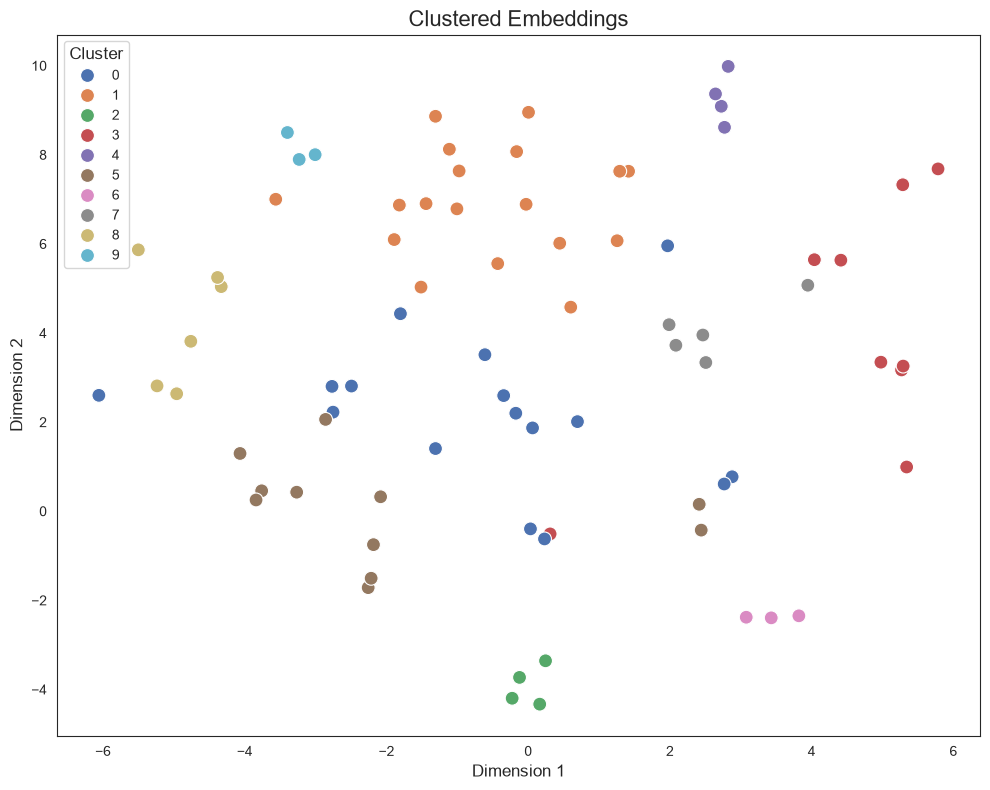

In [78]:
# 클러스터링 결과를 2차원 그래프로 시각화
# 결과를 보면 가까운 공간에 있는 문서들은 비슷한 클러스터로 분류된 것을 확인할 수 있음
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings     # 경고 제거

warnings.filterwarnings("ignore")

# t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

sns.set_style("white")  # seaborn 스타일 설정

plt.figure(figsize=(10, 8))   # 축소된 데이터 플롯
sns.scatterplot(
    x = reduced_data_tsne[:, 0],
    y = reduced_data_tsne[:, 1],
    hue = kmeans.labels_,
    palette = "deep",
    s = 100
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

plt.gcf().patch.set_facecolor("white")  # 배경색 설정

plt.tight_layout()
plt.show()

In [79]:
# 이제 각 클러스터의 중심점(centroid)을 찾아서 그 중심점과 임베딩 값이 가장 가까운 문서를 찾아서 저장해야 함
# closest_indices에 주심점과 가장 가까운 문서의 번호를 추가
import numpy as np

closest_indices = []    # 가장 가까운 점들을 저장할 빈 리스트 생성

for i in range(num_clusters):   # 클러스터 수만큼 반복
    
    # 해당 클러스터 중심점으로부터의 거리 목록 구하기
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # 가장 가까운 점의 인덱스 찾기(argmin을 사용하여 최고 거리 찾기)
    closest_index = np.argmin(distances)

    # 해당 인덱스를 가장 가까운 이덱스 리스트에 추가
    closest_indices.append(closest_index)

In [80]:
# closest_indices를 출력
closest_indices

[np.int64(55),
 np.int64(17),
 np.int64(37),
 np.int64(59),
 np.int64(29),
 np.int64(3),
 np.int64(70),
 np.int64(25),
 np.int64(5),
 np.int64(32)]

In [81]:
# 이 상태로 문서의 순서가 섞여 있으면 나중에 문서를 요약하는 Refine 단게에서 문서의 흐름이 섞일 수 있음
# 문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬
# 출력 결과의 번호는 각 클러스터의 대표 문서가 됨
selected_indices = sorted(closest_indices)
selected_indices

[np.int64(3),
 np.int64(5),
 np.int64(17),
 np.int64(25),
 np.int64(29),
 np.int64(32),
 np.int64(37),
 np.int64(55),
 np.int64(59),
 np.int64(70)]

In [82]:
# 10개의 선택된 문서를 출력.
# 이 과정에서 Document 객체를 사용하여 문서를 생성
# 각 대표 문서의 결과물을 확인

from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='▹ 알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’ 공개 ······················································ 9\n   ▹ 삼성전자, 자체 개발 생성 AI ‘삼성 가우스’ 공개 ··························································· 10\n   ▹ 구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화 ················································ 11\n   ▹ IDC, 2027년 AI 소프트웨어 매출 2,500억 달러 돌파 전망··········································· 12\n   ▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망································ 13'),
 Document(metadata={}, page_content='4. 인력/교육     \n   ▹ 영국 옥스퍼드 인터넷 연구소, AI 기술자의 임금이 평균 21% 높아······························· 18\n   \n   \n \nⅡ. 주요 행사\n   ▹CES 2024 ····························································································································· 19\n   ▹AIMLA 2024 ························································································································· 19'),
 Document(metadata={}, page_content='∙선언은 AI 안전 보장을 위해 국가, 국제기구, 기업,

In [ ]:
# 이전에 생서한 map_refine_chain을 사용하여 Map-Refine 요약을 생성
refined_summary = map_refine_chain.invoke(selected_docs)